  Cloning https://github.com/jkirkby3/pymle.git to C:\Users\Елизавета\AppData\Local\Temp\pip-req-build-5l4u44l8
  Resolved https://github.com/jkirkby3/pymle.git to commit a68ee7b071a9eae8264c649719052ef711b47775
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/jkirkby3/pymle.git 'C:\Users\Елизавета\AppData\Local\Temp\pip-req-build-5l4u44l8'

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

1. ЗАГРУЗКА И EDA (Тесты, Выбросы, Change Points)

Используем CSV fallback...
 Данные: 16074 наблюдений

ЭКСПЛОРАТОРНЫЙ АНАЛИЗ (Задание 1)

• Jarque-Bera: p-value=0.00000 →  НЕ нормальны


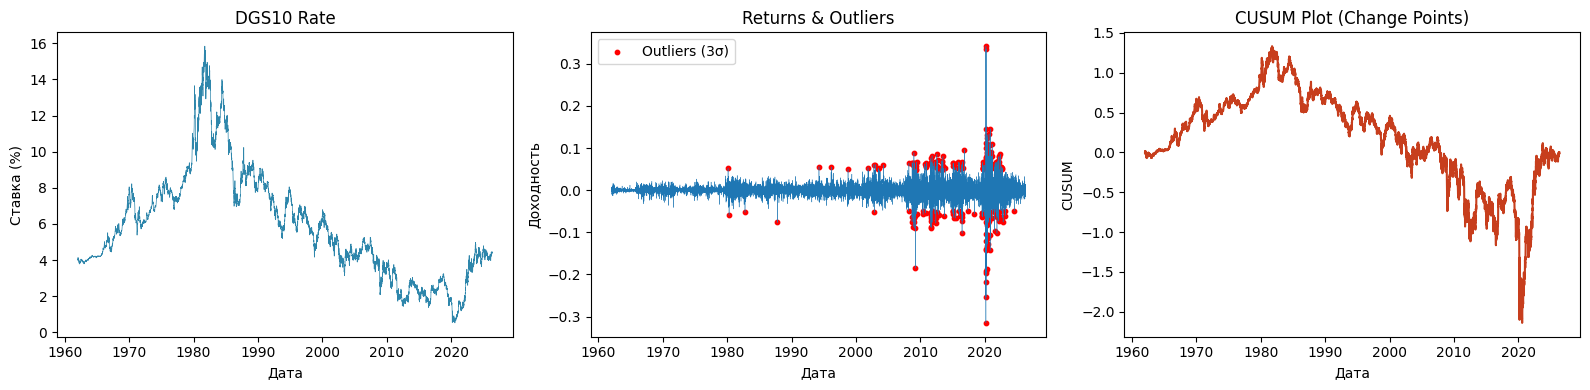

In [8]:
def load_dgs10_robust(start_date='1962-01-01'):
    try:
        from fredapi import Fred
        FRED_KEY = 'ef26db2f860578c918b3b6a1ec02d823'
        fred = Fred(api_key=FRED_KEY)
        df = fred.get_series('DGS10', observation_start=start_date).dropna().to_frame(name='Rate')
        print(" Загрузка: FRED API")
    except:
        print("Используем CSV fallback...")
        url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"
        df_raw = pd.read_csv(url)
        df_raw.columns = ['DATE', 'Rate']
        df = df_raw.set_index(pd.to_datetime(df_raw['DATE']))[['Rate']].dropna()
        
    df = df.sort_index()
    # Используем логарифмические доходности
    df['Return'] = np.log(df['Rate'] / df['Rate'].shift(1)).dropna()
    return df.dropna()

df = load_dgs10_robust()
print(f" Данные: {len(df)} наблюдений")

# EDA АНАЛИЗ 
print("\nЭКСПЛОРАТОРНЫЙ АНАЛИЗ (Задание 1)\n")
ret = df['Return']
jb_stat, jb_p = stats.jarque_bera(ret)
print(f"• Jarque-Bera: p-value={jb_p:.5f} → {' НЕ нормальны' if jb_p < 0.05 else '✓ Нормальны'}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(df.index, df['Rate'], color=COLORS[0], linewidth=0.5)
axes[0].set_title('DGS10 Rate')
axes[0].set_xlabel('Дата')         
axes[0].set_ylabel('Ставка (%)')  

# Выбросы (3 Sigma)
std_dev = ret.std(); mean_ret = ret.mean()
outliers = df[(ret > mean_ret + 3*std_dev) | (ret < mean_ret - 3*std_dev)]
axes[1].plot(df.index, ret, linewidth=0.3)
if not outliers.empty:
    axes[1].scatter(outliers.index, outliers['Return'], color='red', s=10, label='Outliers (3σ)')
axes[1].set_title('Returns & Outliers'); axes[1].legend()
axes[1].set_xlabel('Дата')          
axes[1].set_ylabel('Доходность')

# Change Points (CUSUM)
cumsum = (ret - ret.mean()).cumsum()
axes[2].plot(df.index, cumsum, color=COLORS[3])
axes[2].set_title('CUSUM Plot (Change Points)')
axes[2].set_xlabel('Дата')      
axes[2].set_ylabel('CUSUM') 

plt.tight_layout()
plt.show()

 2. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ И ФУНКЦИЙ ПРАВДОПОДОБИЯ

In [9]:
def get_models():
    return {
        'BM': (lambda x,p: p[0], lambda x,p: p[1], ['mu','sigma'], [(-1,1),(0.01,5)], [0.0,0.5]),
        'GBM': (lambda x,p: p[0]*x, lambda x,p: p[1]*x, ['mu','sigma'], [(-1,1),(0.01,2)], [0.01,0.2]),
        'OU': (lambda x,p: p[0]*(p[1]-x), lambda x,p: p[2], ['kappa','mu','sigma'], [(0.01,10),(0,20),(0.01,5)], [0.5,5,0.5]),
        'CIR': (lambda x,p: p[0]*(p[1]-x), lambda x,p: p[2]*np.sqrt(np.maximum(x,1e-8)), ['kappa','mu','sigma'], [(0.01,10),(0,20),(0.01,2)], [0.5,5,0.3]),
        'CEV': (lambda x,p: p[0]*(p[1]-x), lambda x,p: p[2]*np.power(np.maximum(x,1e-8),p[3]), ['kappa','mu','sigma','gamma'], [(0.01,10),(0,20),(0.01,3),(0.1,2)], [0.5,5,0.3,0.6]),
        'CKLS': (lambda x,p: p[0]+p[1]*x, lambda x,p: p[2]*np.power(np.maximum(x,1e-8),p[3]), ['alpha','beta','sigma','gamma'], [(-5,5),(-5,5),(0.01,3),(0.1,2)], [0.01,-0.01,0.3,0.6])
    }

# раЛИЧНЫЕ МЕТОДЫ ДИСКРЕТИЗАЦИИ
def log_likelihood_euler(x, dt, drift, diffusion, params):
    ll = 0
    for i in range(len(x)-1):
        mu = drift(x[i], params) * dt
        sig2 = diffusion(x[i], params)**2 * dt
        if sig2 <= 1e-12: return -1e10
        ll += -0.5 * (np.log(2*np.pi*sig2) + (x[i+1]-x[i]-mu)**2 / sig2)
    return ll

def log_likelihood_shoji_ozaki(x, dt, drift, diffusion, params):    # Метод Шодзи-Озаки: использует производную сноса для коррекции

    ll = 0
    for i in range(len(x)-1):
        mu = drift(x[i], params)
        eps = 1e-6
        # Численная производная mu' (Jacobian)
        mu_deriv = (drift(x[i] + eps, params) - mu) / eps
        
        eff_mu = mu * dt
        # Коррекция дисперсии на exp(mu' * dt)
        eff_sig2 = diffusion(x[i], params)**2 * dt * np.exp(mu_deriv * dt)
        
        if eff_sig2 <= 1e-12: return -1e10
        ll += -0.5 * (np.log(2*np.pi*eff_sig2) + (x[i+1]-x[i]-eff_mu)**2 / eff_sig2)
    return ll

def log_likelihood_kessler(x, dt, drift, diffusion, params):  # Метод Кесслера: разложение Тейлора 2-го порядка

    ll = 0
    for i in range(len(x)-1):
        mu = drift(x[i], params)
        sig = diffusion(x[i], params)
        dt2 = dt**2
        
        eff_mu = mu * dt + 0.5 * mu * mu * dt2 
        eff_sig2 = sig**2 * dt * (1 + mu * dt)
        
        if eff_sig2 <= 1e-12: return -1e10
        ll += -0.5 * (np.log(2*np.pi*eff_sig2) + (x[i+1]-x[i]-eff_mu)**2 / eff_sig2)
    return ll

def fit_model_mle(x, dt, model_def, method='euler'):
    drift, diffusion, params, bounds, guess = model_def
    ll_func = {'euler': log_likelihood_euler, 'kessler': log_likelihood_kessler, 'shoji_ozaki': log_likelihood_shoji_ozaki}[method]
    
    def neg_ll(p):
        try: return -ll_func(x, dt, drift, diffusion, p)
        except: return 1e10
    
    res = minimize(neg_ll, guess, method='L-BFGS-B', bounds=bounds)
    if res.success:
        ll = -res.fun; k = len(res.x); n = len(x)-1
        return {'params': dict(zip(params, res.x)), 'll': ll, 'aic': 2*k-2*ll, 'bic': k*np.log(n)-2*ll, 'success': True}
    return {'success': False}

 3. ЗАПУСК ОЦЕНКИ (Задание 2, 3, 4)


 Оценка: 16074 наблюдений
------------------------------------------------------------
BM   | euler        | BIC=-42322.74
BM   | kessler      | BIC=-42322.74
BM   | shoji_ozaki  | BIC=-42322.74
GBM  | euler        | BIC=-34957.01
GBM  | kessler      | BIC=-34959.27
GBM  | shoji_ozaki  | BIC=-34957.01
OU   | euler        | BIC=-42315.10
OU   | kessler      | BIC=-42312.25
OU   | shoji_ozaki  | BIC=-42315.10
CIR  | euler        | BIC=-43402.49
CIR  | kessler      | BIC=-43405.05
CIR  | shoji_ozaki  | BIC=-43402.49
CEV  | euler        | BIC=-43946.78
CEV  | kessler      | BIC=-43944.99
CEV  | shoji_ozaki  | BIC=-43947.35
CKLS | euler        | BIC=-43947.35
CKLS | kessler      | BIC=-43945.53
CKLS | shoji_ozaki  | BIC=-43947.35

 СВОДНАЯ ТАБЛИЦА (AIC/BIC)
Model      Method                                             Params_str           AIC           BIC
 CKLS shoji_ozaki alpha=0.4134, beta=-0.0693, sigma=0.5792, gamma=0.3240 -43978.090658 -43947.351073
 CKLS       euler alpha=0.4146, be

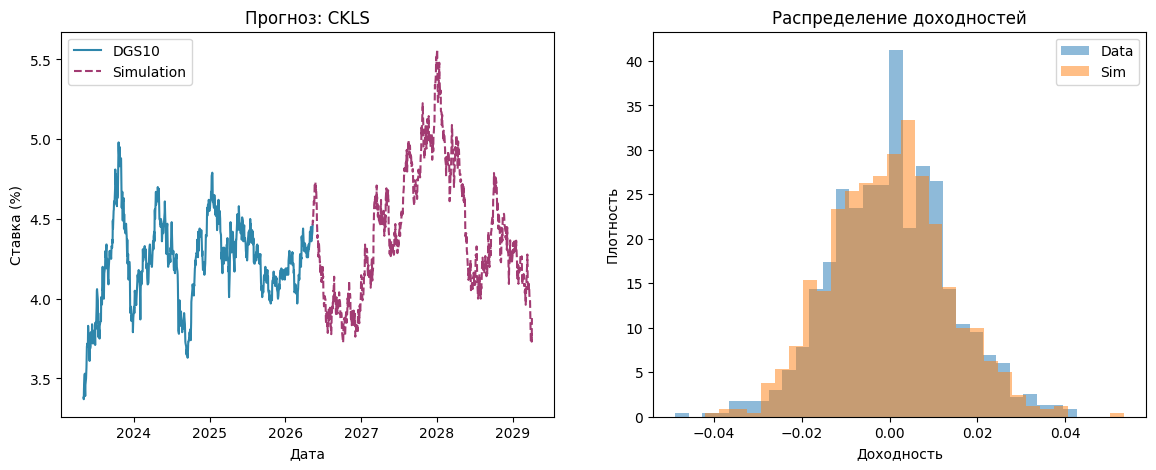

In [10]:
def run_estimation(df, freq=252):
    models = get_models()
    methods = ['euler', 'kessler', 'shoji_ozaki']
    x = df['Rate'].values; dt = 1.0 / freq
    results = []
    
    print(f"\n Оценка: {len(x)} наблюдений\n" + "-"*60)
    for name, mdef in models.items():
        for method in methods:
            res = fit_model_mle(x, dt, mdef, method)
            if res['success']:
                results.append({
                    'Model': name, 'Method': method,
                    'Params': {k: f"{v:.4f}" for k,v in res['params'].items()},
                    'LogLik': res['ll'], 'AIC': res['aic'], 'BIC': res['bic']
                })
                print(f"{name:4s} | {method:12s} | BIC={res['bic']:8.2f}")
    return pd.DataFrame(results)

results = run_estimation(df)

# Сводная таблица
print( "\n СВОДНАЯ ТАБЛИЦА (AIC/BIC)\n" + "="*70)
results['Params_str'] = results['Params'].apply(lambda d: ', '.join(f"{k}={v}" for k,v in d.items()))
results_table = results[['Model','Method','Params_str','AIC','BIC']].sort_values('BIC')

print(results_table.to_string(index=False))

best = results.loc[results['BIC'].idxmin()]
print(f"\n Лучшая модель: {best['Model']} ({best['Method']}), BIC={best['BIC']:.2f}")

#  PYMLE
try:
    from pymle.fit.AnalyticalMLE import AnalyticalMLE
    from pymle.core.TransitionDensity import EulerDensity
    from pymle.models import CKLS

    print("\n Оценка через pymle (CKLS, Euler density):")
    x_pymle  = df['Rate'].values
    dt_pymle = 1 / 252
    ckls_model   = CKLS()
    ckls_density = EulerDensity(ckls_model)
    ckls_bounds  = [(-5, 5), (-5, 5), (0.01, 3), (0.1, 2)]
    estimator_pymle = AnalyticalMLE(x_pymle, ckls_bounds, dt_pymle, density=ckls_density)
    est_pymle = estimator_pymle.estimate_params(np.array([0.01, -0.01, 0.3, 0.6]))

    CKLS_PARAM_NAMES = ['alpha', 'beta', 'sigma', 'gamma']
    pymle_params_dict = {k: f"{v:.4f}" for k, v in zip(CKLS_PARAM_NAMES, est_pymle.params)}
    print(f"pymle CKLS: {pymle_params_dict}")
    print(f"BIC (pymle): {est_pymle.bic:.2f}")

    results_pymle = pd.DataFrame([{
        'Model':  'CKLS',
        'Method': 'pymle_euler',
        'Params':  pymle_params_dict,
        'LogLik':  est_pymle.log_like,
        'AIC':     est_pymle.aic,
        'BIC':     est_pymle.bic,
    }])
except Exception as _e:
    print(f"\nℹ pymle недоступна ({_e}) — пропускаем")
    results_pymle = pd.DataFrame()


def plot_model_fit(df, results):
    best = results.loc[results['BIC'].idxmin()]
    models = get_models()
    drift, diffusion, params, _, _ = models[best['Model']]
    params_num = np.array([float(v) for v in best['Params'].values()])
    
    np.random.seed(42)
    x_sim = np.zeros(252*3 + 1)
    x_sim[0] = df['Rate'].iloc[-1]; dt = 1/252
    for i in range(252*3):
        mu = drift(x_sim[i], params_num) * dt
        sig = diffusion(x_sim[i], params_num) * np.sqrt(dt)
        x_sim[i+1] = x_sim[i] + mu + sig * np.random.normal()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    recent = df['Rate'].iloc[-756:]
    axes[0].plot(recent.index, recent, label='DGS10', color=COLORS[0])
    axes[0].plot(pd.date_range(start=recent.index[-1], periods=len(x_sim), freq='B'), x_sim, '--', label='Simulation', color=COLORS[1])
    axes[0].set_title(f'Прогноз: {best["Model"]}'); axes[0].legend()
    axes[0].set_xlabel('Дата')         
    axes[0].set_ylabel('Ставка (%)')    
    
    ret_data = df['Return'].iloc[-756:]
    ret_sim = pd.Series(x_sim).diff() / pd.Series(x_sim).shift(1)
    axes[1].hist(ret_data, bins=30, density=True, alpha=0.5, label='Data')
    axes[1].hist(ret_sim.dropna(), bins=30, density=True, alpha=0.5, label='Sim')
    axes[1].set_title('Распределение доходностей'); axes[1].legend()
    axes[1].set_xlabel('Доходность') 
    axes[1].set_ylabel('Плотность')

    plt.show()

plot_model_fit(df, results)

 ЗАДАНИЕ 6: Сравнение и визуализация лучших моделей


 Топ-3 модели по BIC: CKLS, CEV, CIR
 Лучшая: CKLS (shoji_ozaki)


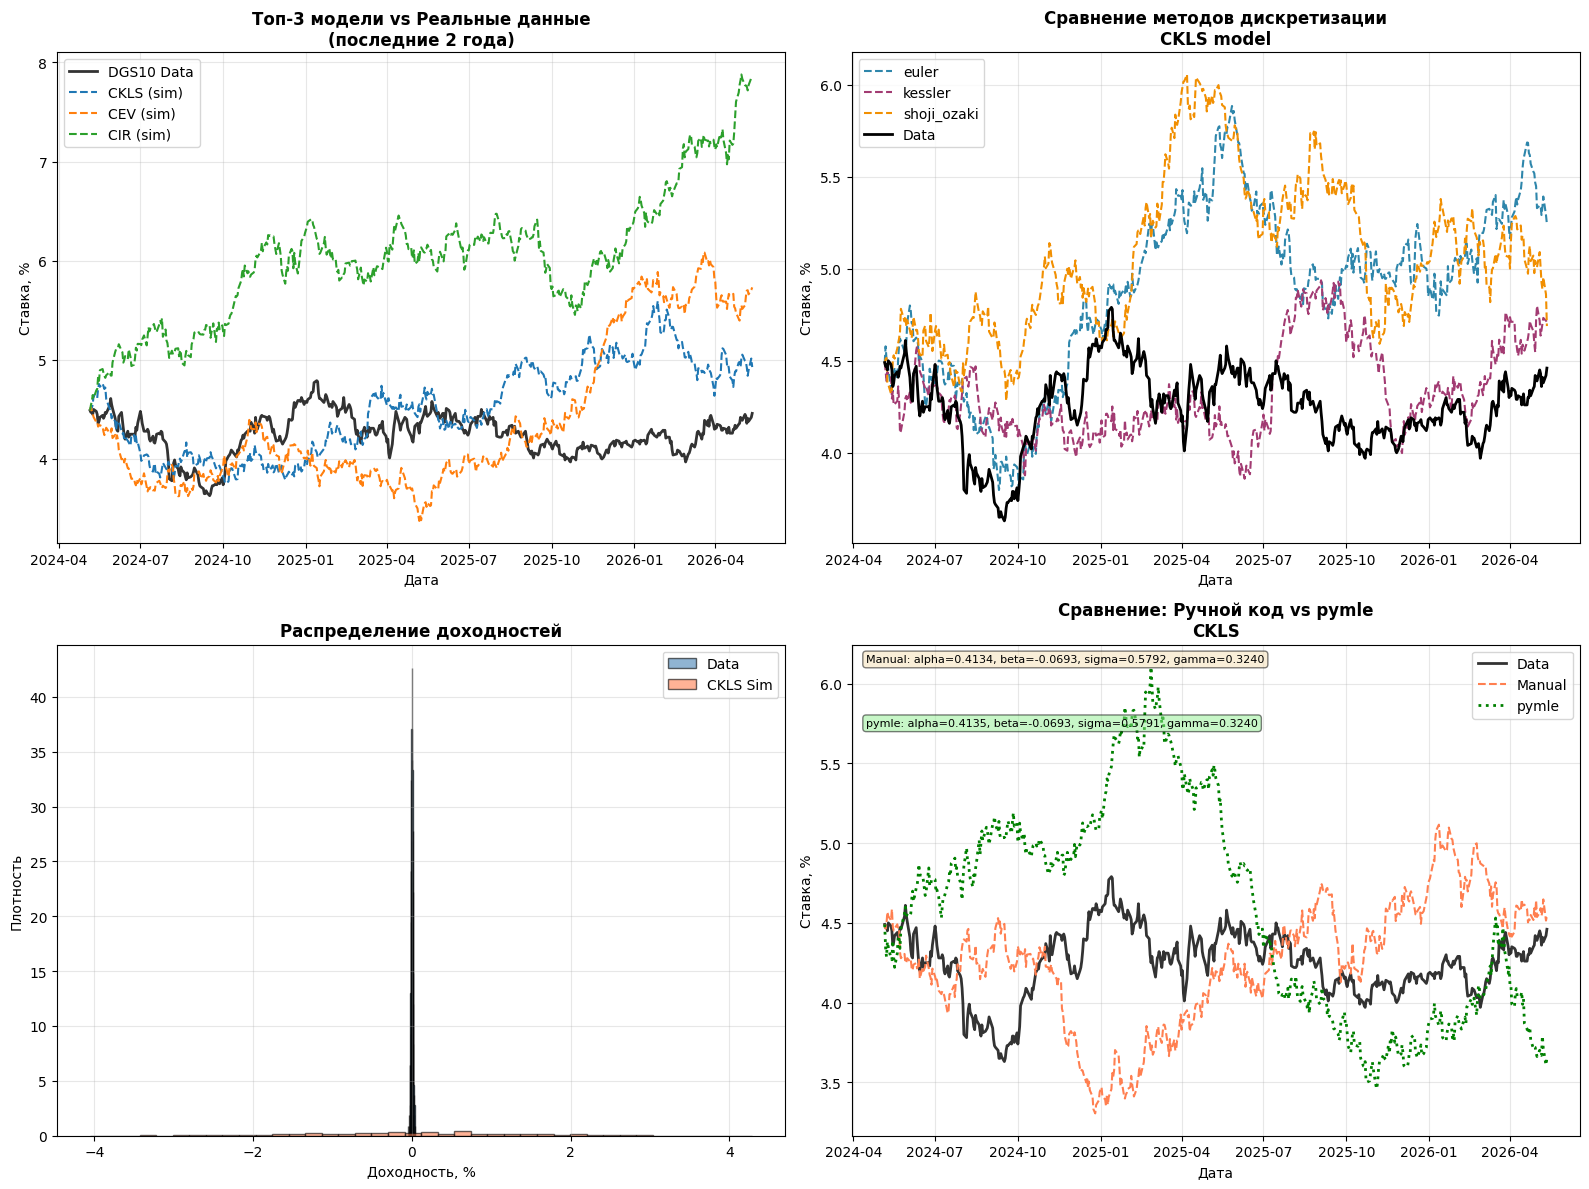

Модель: CKLS
Метод           | BIC          | Params                                            
Ручной код      | -43947.35    | alpha=0.4134, beta=-0.0693, sigma=0.5792, gamma=0.3240
pymle           | -43947.35    | alpha=0.4135, beta=-0.0693, sigma=0.5791, gamma=0.3240

Δ BIC: 0.0000 (совпадает)


In [11]:
def plot_model_comparison_full(df, results_manual, results_pymle=None):  # сравнение моделей и методов

    
    # Определяем лучшие модели
    best_manual = results_manual.loc[results_manual['BIC'].idxmin()]
    top3_models = results_manual.groupby('Model')['BIC'].min().nsmallest(3).index.tolist()
    
    print(f"\n Топ-3 модели по BIC: {', '.join(top3_models)}")
    print(f" Лучшая: {best_manual['Model']} ({best_manual['Method']})")
    
    #  Симуляция топ-3 моделей на исторических данных (последние 2 года)
    n_hist = 504  # 2 года
    x_hist = df['Rate'].iloc[-n_hist:].values
    dt = 1/252
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    models = get_models()
    np.random.seed(42)
    
    #  Наложение топ-3 моделей на данные 
    ax1 = axes[0, 0]
    ax1.plot(df.index[-n_hist:], x_hist, 'k-', linewidth=2, label='DGS10 Data', alpha=0.8)
    
    for i, model_name in enumerate(top3_models):
        # Берем лучшую версию модели (по BIC)
        model_res = results_manual[results_manual['Model'] == model_name].sort_values('BIC').iloc[0]
        drift, diffusion, params, _, _ = models[model_name]
        params_num = np.array([float(v) for v in model_res['Params'].values()])
        
        # Симуляция на исторических данных
        x_sim = np.zeros(n_hist)
        x_sim[0] = x_hist[0]
        for t in range(n_hist-1):
            mu = drift(x_sim[t], params_num) * dt
            sig = diffusion(x_sim[t], params_num) * np.sqrt(dt)
            x_sim[t+1] = x_sim[t] + mu + sig * np.random.normal()
        
        ax1.plot(df.index[-n_hist:], x_sim, '--', linewidth=1.5, label=f'{model_name} (sim)')
    
    ax1.set_title('Топ-3 модели vs Реальные данные\n(последние 2 года)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Ставка, %')
    ax1.set_xlabel('Дата')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    #  Сравнение методов для лучшей модели 
    ax2 = axes[0, 1]
    best_model_name = best_manual['Model']
    drift, diffusion, params, _, _ = models[best_model_name]
    params_num = np.array([float(v) for v in best_manual['Params'].values()])
    
    methods = ['euler', 'kessler', 'shoji_ozaki']
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    for method, color in zip(methods, colors):
        x_sim = np.zeros(n_hist)
        x_sim[0] = x_hist[0]
        for t in range(n_hist-1):
            # Используем соответствующую функцию правдоподобия для симуляции
            if method == 'euler':
                mu = drift(x_sim[t], params_num) * dt
                sig = diffusion(x_sim[t], params_num) * np.sqrt(dt)
            elif method == 'kessler':
                mu_val = drift(x_sim[t], params_num)
                sig_val = diffusion(x_sim[t], params_num)
                mu = (mu_val * dt + 0.5 * mu_val * mu_val * dt**2)
                sig = sig_val * np.sqrt(dt * (1 + mu_val * dt))
            else:  # shoji_ozaki
                mu_val = drift(x_sim[t], params_num)
                eps = 1e-6
                mu_deriv = (drift(x_sim[t] + eps, params_num) - mu_val) / eps
                mu = mu_val * dt
                sig = diffusion(x_sim[t], params_num) * np.sqrt(dt * np.exp(mu_deriv * dt))
            
            x_sim[t+1] = x_sim[t] + mu + sig * np.random.normal()
        
        ax2.plot(df.index[-n_hist:], x_sim, '--', color=color, linewidth=1.5, label=f'{method}')
    
    ax2.plot(df.index[-n_hist:], x_hist, 'k-', linewidth=2, label='Data')
    ax2.set_title(f'Сравнение методов дискретизации\n{best_model_name} model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Ставка, %')
    ax2.set_xlabel('Дата')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Распределение доходностей (данные vs лучшая модель) 
    ax3 = axes[1, 0]
    ret_data = df['Return'].iloc[-n_hist:]
    
    # Симуляция лучшей модели
    best_drift, best_diffusion, best_params, _, _ = models[best_model_name]
    best_params_num = np.array([float(v) for v in best_manual['Params'].values()])
    x_sim_best = np.zeros(n_hist)
    x_sim_best[0] = x_hist[0]
    for t in range(n_hist-1):
        mu = best_drift(x_sim_best[t], best_params_num) * dt
        sig = best_diffusion(x_sim_best[t], best_params_num) * np.sqrt(dt)
        x_sim_best[t+1] = x_sim_best[t] + mu + sig * np.random.normal()
    
    ret_sim = pd.Series(x_sim_best).diff() / pd.Series(x_sim_best).shift(1) * 100
    ret_sim = ret_sim.iloc[1:].dropna()
    
    ax3.hist(ret_data.dropna(), bins=40, density=True, alpha=0.6, label='Data', color='steelblue', edgecolor='black')
    ax3.hist(ret_sim.dropna(), bins=40, density=True, alpha=0.6, label=f'{best_model_name} Sim', color='coral', edgecolor='black')
    ax3.set_title('Распределение доходностей', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Доходность, %')
    ax3.set_ylabel('Плотность')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Сравнение с pymle
    ax4 = axes[1, 1]
    if results_pymle is not None and not results_pymle.empty:
        best_pymle = results_pymle[results_pymle['Model'] == best_model_name].sort_values('BIC').iloc[0]
        pymle_params = np.array([float(v) for v in best_pymle['Params'].values()])
        
        # Симуляция pymle
        x_sim_pymle = np.zeros(n_hist)
        x_sim_pymle[0] = x_hist[0]
        for t in range(n_hist-1):
            mu = best_drift(x_sim_pymle[t], pymle_params) * dt
            sig = best_diffusion(x_sim_pymle[t], pymle_params) * np.sqrt(dt)
            x_sim_pymle[t+1] = x_sim_pymle[t] + mu + sig * np.random.normal()
        
        ax4.plot(df.index[-n_hist:], x_hist, 'k-', linewidth=2, label='Data', alpha=0.8)
        ax4.plot(df.index[-n_hist:], x_sim_best, '--', color='coral', linewidth=1.5, label='Manual')
        ax4.plot(df.index[-n_hist:], x_sim_pymle, ':', color='green', linewidth=2, label='pymle')
        ax4.set_title(f'Сравнение: Ручной код vs pymle\n{best_model_name}', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Ставка, %')
        ax4.set_xlabel('Дата') 
        ax4.legend()
        
        # Добавляем таблицу сравнения параметров
        ax4.text(0.02, 0.98, f"Manual: {', '.join([f'{k}={v}' for k,v in best_manual['Params'].items()])}", 
                 transform=ax4.transAxes, fontsize=8, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax4.text(0.02, 0.85, f"pymle: {', '.join([f'{k}={v}' for k,v in best_pymle['Params'].items()])}", 
                 transform=ax4.transAxes, fontsize=8, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    else:
        ax4.plot(df.index[-n_hist:], x_hist, 'k-', linewidth=2)
        ax4.plot(df.index[-n_hist:], x_sim_best, '--', color='coral', linewidth=1.5)
        ax4.set_title(f'{best_model_name} (pymle не доступна)', fontsize=12)
        ax4.text(0.5, 0.5, 'pymle не установлен', ha='center', va='center', transform=ax4.transAxes)
    
    ax4.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    if results_pymle is not None and not results_pymle.empty:
        best_pymle = results_pymle[results_pymle['Model'] == best_model_name].sort_values('BIC').iloc[0]
        print(f"Модель: {best_model_name}")
        print(f"{'Метод':<15} | {'BIC':<12} | {'Params':<50}")
        print(f"{'Ручной код':<15} | {best_manual['BIC']:<12.2f} | {', '.join([f'{k}={v}' for k,v in best_manual['Params'].items()])}")
        print(f"{'pymle':<15} | {best_pymle['BIC']:<12.2f} | {', '.join([f'{k}={v}' for k,v in best_pymle['Params'].items()])}")
        
        # Разница в BIC
        bic_diff = abs(best_manual['BIC'] - best_pymle['BIC'])
        print(f"\nΔ BIC: {bic_diff:.4f} {'(совпадает)' if bic_diff < 0.1 else '(есть расхождение)'}")
    else:
        print("pymle не установлена - сравнение невозможно")

plot_model_comparison_full(df, results, results_pymle if 'results_pymle' in locals() else None)

Обнаружение точек смены тренда 

 Найдено точек смены тренда: 104
 Первые 5 точек:
   • 1962-01-05 | Ставка: 4.02%
   • 1962-08-29 | Ставка: 3.96%
   • 1963-04-29 | Ставка: 3.95%
   • 1964-02-20 | Ставка: 4.14%
   • 1964-09-21 | Ставка: 4.19%


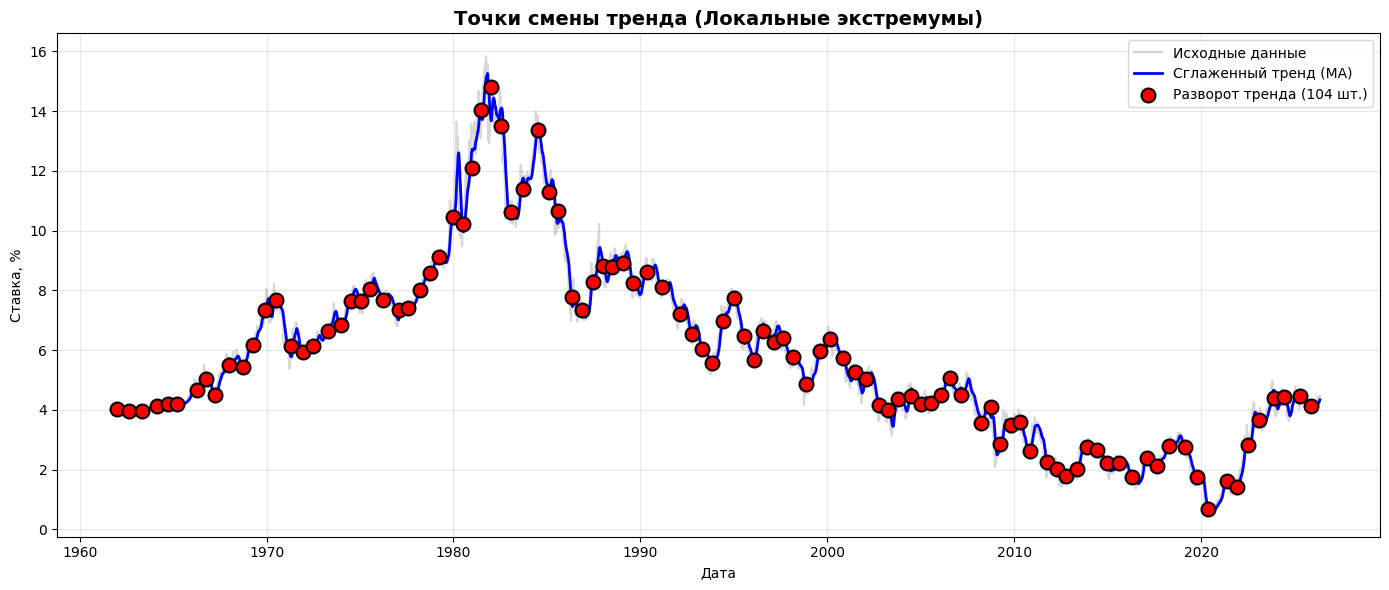

In [28]:
def find_trend_reversals(df, smooth_window=30, min_days_dist=60):

    smoothed = df['Rate'].rolling(window=smooth_window, min_periods=1).mean()
    
    #  Вычисляем наклон (производную)
    slope = smoothed.diff()
    
    
    # Создаем маску: где знак изменился
    sign_change = np.sign(slope) * np.sign(slope.shift(1))
    
    # -1 означает смену знака
    change_indices = np.where(sign_change == -1)[0]
    
    #  Фильтруем: убираем точки, которые стоят слишком близко друг к другу
    filtered_points = []
    if len(change_indices) > 0:
        last_idx = -np.inf
        for idx in change_indices:
            if idx - last_idx >= min_days_dist:
                filtered_points.append(idx)
                last_idx = idx
    
    return smoothed, filtered_points

# Окно сглаживания = 45 дней. Дистанция = 120 дней, чтобы не находить слишком частые "дрожания".
smoothed_curve, change_points = find_trend_reversals(df, smooth_window=45, min_days_dist=120)

print(f" Найдено точек смены тренда: {len(change_points)}")
if len(change_points) > 0:
    print(" Первые 5 точек:")
    for i, idx in enumerate(change_points[:5]):
        print(f"   • {df.index[idx].strftime('%Y-%m-%d')} | Ставка: {df['Rate'].iloc[idx]:.2f}%")


fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Rate'], color='gray', alpha=0.3, label='Исходные данные')

ax.plot(df.index, smoothed_curve, color='blue', linewidth=2, label='Сглаженный тренд (MA)')

# Рисуем найденные точки
if change_points:
    cp_dates = [df.index[i] for i in change_points]
    cp_values = [df['Rate'].iloc[i] for i in change_points]
    
    # Маркеры (красные круги)
    ax.scatter(cp_dates, cp_values, color='red', s=100, zorder=5, 
               label=f'Разворот тренда ({len(change_points)} шт.)', 
               edgecolors='black', linewidth=1.5)

ax.set_title('Точки смены тренда (Локальные экстремумы)', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Ставка, %')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()